In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
from scipy.sparse import coo_matrix
from scipy.sparse import csr_matrix
from kmeans import KMeansClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import pairwise_distances, mean_absolute_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
warnings.filterwarnings("ignore")

### Section 1 - Data pre-proccessing
<p style="text-align: justify">
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, the data that we want to process are loaded, inspected and converted to the final format that will be fed to the clustering and recommendation algorithms.
</p>

#### Section 1.1 - Data loading and inspection.
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this stage, the data is loaded and brought to a format suitable for further processing. The file containing the data is loaded. The entries of the intial file are strings containing commas, so the entries are split by the commas and a list of lists is created, which in turn is converted to a pandas dataframe. Descriptive names are given to the columns of the dataframe. The data of the rating column are converted to numeric values and the data of the date column are converted to datetime objects. This ensures that operations like subtractions, additions, comparisons etc. will be correctly applied to the data.</p>

In [2]:
# Load the .npy file
data = np.load('Dataset.npy', allow_pickle=True)

# Reshape the data to a list of lists
data_list = [entry.split(',') for entry in data]

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data_list, columns=['user_id', 'movie_id', 'rating', 'date'])

# Convert 'rating' to numeric type and 'date' to datetime type
df['rating'] = pd.to_numeric(df['rating'])
df['date'] = pd.to_datetime(df['date'])

# Print a sample of the data
df.head()

,user_id,movie_id,rating,date
0,ur4592644,tt0120884,10,2005-01-16
1,ur3174947,tt0118688,3,2005-01-16
2,ur3780035,tt0387887,8,2005-01-16
3,ur4592628,tt0346491,1,2005-01-16
4,ur3174947,tt0094721,8,2005-01-16


#### Section 1.2 Finding the number of unique users and movies
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, we find the number of unique users (|𝑼|) and the number of unique movies/items (|𝑰|) that the dataset contains.</p>

In [3]:
# Display the results
print("Number of unique users (|𝑼|):", df['user_id'].nunique())
print("Number of unique items (|𝑰|):", df['movie_id'].nunique())

Number of unique users (|𝑼|): 1499238
Number of unique items (|𝑰|): 351109


#### Section 1.3 Limiting the problem space based on Rmin and Rmax
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, we are limiting the problem space on which we will be running our algorithms, based on Rmin, the minimum number of ratings a user should have made in order to be inlcuded in the reduced problem space, and Rmax, the maximum number of ratings they should have made. These two bounds should represent a useful area of the data, representing users that have made enough reviews to be considered regulars on a movie rating platform, while excluding users that their engagment does not provide useful or reliable behavioral data, like users that have made very few ratings, which might indicate that a user might not leave ratings or use the platform regularly or even that a user might have made an account in order to target a few specific movies, either to boost their ratings or review-bomb them. Another category of users that may not provide very useful behavioral data are users that rate a lot of movies, which are outliers and do not present a very clear behavioral pattern. In summary, we limit the problem space to a set of reasonably regular users in order to have meaningful data.</p>
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In the following code section, we group the entries of the data dataframe by the user ids and and get the number of ratings that each user has made. We then filter the grouped data by Rmin and Rmax and get a list of user ids of the users that fit our criteria.</p>

In [4]:
R_min = 30  # Minimum required number of ratings per user
R_max = 35 # Maximum allowed number of ratings per user

# Group by 'user_id' and count the number of ratings per user
user_rating_counts = df.groupby('user_id').size()

# Filter users based on the rating count constraints
filtered_users = user_rating_counts[(user_rating_counts >= R_min) & (user_rating_counts <= R_max)].index

# Filter the DataFrame to include only rows with the filtered users
filtered_df = df[df['user_id'].isin(filtered_users)]

# Get unique user ids (U_hat) and movie ids (I_hat) from the filtered DataFrame
U_hat = filtered_df['user_id'].unique()
I_hat = filtered_df['movie_id'].unique()

print("Number of filtered unique users (|𝑼_hat|):", len(U_hat))
print("Number of filtered unique items (|𝑰_hat|):", len(I_hat))

Number of filtered unique users (|𝑼_hat|): 2496
Number of filtered unique items (|𝑰_hat|): 31784


#### Section 1.4 Inspecting the filtered data using histograms
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, we plot some frequency histograms for the data filtered in the previous sections, giving us insights on user engagement and how it fluctuates through time.</p>
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The below code, plots a histogram that shows us how many users made how many ratings. We notice that the higher the number of ratings per user, the less the users that have made such a high number of ratings are. This shows us that users tend to engage with a limited number of movies. If the histogram was to continue for higher numbers of ratings, the number of users would drop further, which indicates that the more ratings a user has made, the less useful their preferences become, as there are less users like them.</p>

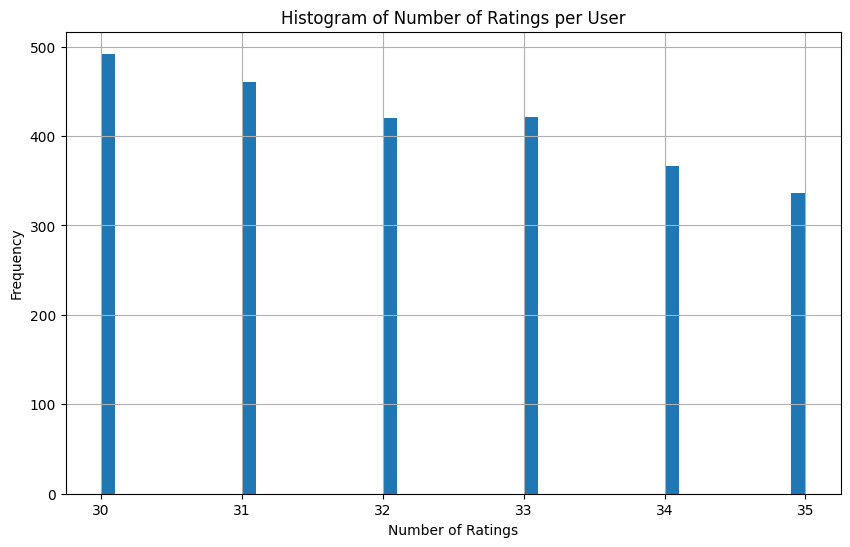

In [5]:
# Plot histogram for the number of ratings per user
plt.figure(figsize=(10, 6))
user_rating_counts_filtered = filtered_df.groupby('user_id').size()
user_rating_counts_filtered.hist(bins=50)
plt.title('Histogram of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The below code, plots a histogram that shows us how many users made ratings in what span of days. We notice that the greater the span, the less the users, which shows us that users tend to engage with the platform for a limited time. This indicates that the larger the period a user engages with the platform, the lesser their data are useful, as there are less users like them.</p>

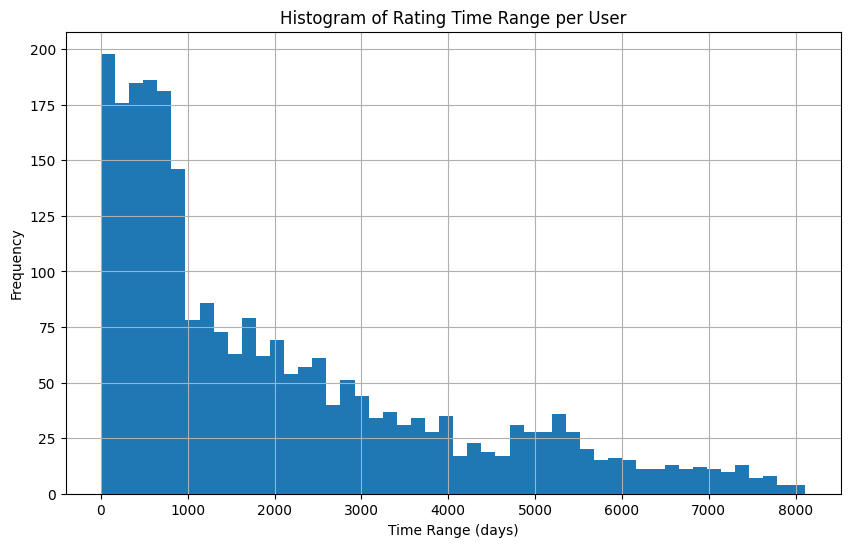

In [6]:
# Histogram of the time range of ratings per user
plt.figure(figsize=(10, 6))
rating_time_range = filtered_df.groupby('user_id')['date'].apply(lambda x: (x.max() - x.min()).days)
rating_time_range.hist(bins=50)
plt.title('Histogram of Rating Time Range per User')
plt.xlabel('Time Range (days)')
plt.ylabel('Frequency')
plt.show()

#### Section 1.5 Creating preference vectors from our data
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, we create preference vectors for the users of the filtered dataset from section 1.3. This vectors correspond to the ratings of each user for all the movies that the filtered users have rated, even for the ones that the user has not rated. The matrix of the preference vectros of all users wull be used as input to our algorithms.</p>
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We first map the user and movie ids to integer indexes, in order to make data access at later points easier and then create a sparse matrix of the user preference vectors. We store the matrix as a csr matrix, which is a list of the coordinates of the matrix where the value is different than zero and the values at these coordinates. This is a more memory efficient format than a normal matrix and given the large number of our data and their sparsity, it is  suitable for this application. An example of a row of the matrix is provided.</p>

In [12]:
# Create mappings for user_id and movie_id to integer indices
user_mapping = {user_id: idx for idx, user_id in enumerate(U_hat)}
movie_mapping = {movie_id: idx for idx, movie_id in enumerate(I_hat)}

# Map user_id and movie_id to integer indices in the filtered dataframe
filtered_df['user_idx'] = filtered_df['user_id'].map(user_mapping)
filtered_df['movie_idx'] = filtered_df['movie_id'].map(movie_mapping)

# Create the sparse user-item matrix
user_item_matrix = coo_matrix((filtered_df['rating'], (filtered_df['user_idx'], filtered_df['movie_idx'])), shape=(len(U_hat), len(I_hat))).tocsr()

# Display some information about the sparse matrix
print(f"Sparse matrix shape: {user_item_matrix.shape}")
print(f"Number of non-zero entries: {user_item_matrix.nnz}")
print("Example for user 0: \n", user_item_matrix[0])

{'ur1123934': 0, 'ur0386545': 1, 'ur3769621': 2, 'ur1681420': 3, 'ur1117092': 4, 'ur4453277': 5, 'ur3698433': 6, 'ur1140696': 7, 'ur2220913': 8, 'ur0692247': 9, 'ur2256118': 10, 'ur0355873': 11, 'ur2100296': 12, 'ur1560900': 13, 'ur1919558': 14, 'ur0704672': 15, 'ur3948010': 16, 'ur1380543': 17, 'ur1255798': 18, 'ur2126454': 19, 'ur1993594': 20, 'ur2112101': 21, 'ur0610462': 22, 'ur4602452': 23, 'ur4071528': 24, 'ur4304070': 25, 'ur1367081': 26, 'ur3064679': 27, 'ur4623556': 28, 'ur3597697': 29, 'ur0270834': 30, 'ur3957278': 31, 'ur2203416': 32, 'ur4062701': 33, 'ur1560419': 34, 'ur0836984': 35, 'ur0328088': 36, 'ur1682702': 37, 'ur1875805': 38, 'ur0084002': 39, 'ur0430427': 40, 'ur0503867': 41, 'ur0446676': 42, 'ur2152844': 43, 'ur1388762': 44, 'ur2967746': 45, 'ur2799184': 46, 'ur2553391': 47, 'ur2549960': 48, 'ur0180277': 49, 'ur2615539': 50, 'ur0152538': 51, 'ur2793307': 52, 'ur2425535': 53, 'ur0383463': 54, 'ur2250153': 55, 'ur1869359': 56, 'ur0348095': 57, 'ur0139267': 58, 'ur035

### Section 2 -  Data Clustering Algorithms
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, we use a modified version of the k-means algorithm to cluster the users based on their preference vectors. We cluster the users in various numbers of clusters, using a modified euclidean and a modified cosine distance function, plot the results of the clusterings and comment on the effectiveness of the two used distance metrics. <b>For more information on the KMeansClustering class used to cluster the users, see the kmeans.ipynb file, where the code that implements the algorithm resides.</b></p>
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The plot _clusters function will be used to plot the results of each run of the k-means algorithm. It receives the results of the algorithm, reduced to two dimensions.</p>

In [8]:
# Function to plot clusters
def plot_clusters(reduced_data, labels, title):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='tab20', marker='o')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar(scatter)
    plt.show()

<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We specifiy the numbers of clusters (L_values) we want to cluster our data into and the metrics we want to use (metrics). For each L value, we perform the k-means algorithm for both metrics. The random_state parameter of the KMeansClustering has the same function as the parameter of the same name for the constructor of the KMeans class form scikit. It is set manually so the results are consistent with every run of the program. We  also pass into the kmeans object the number of clusters we want to split our data into and the distance metric we want to use for calculating the distance of a preference vector form the centroids of the clusters. After the clustering is complete, we reduce the dimensionality of the results to 50 dimensions using SVD and then to 2 dimensions using t-SNE and pass the reduced results to the plotting function.</p>

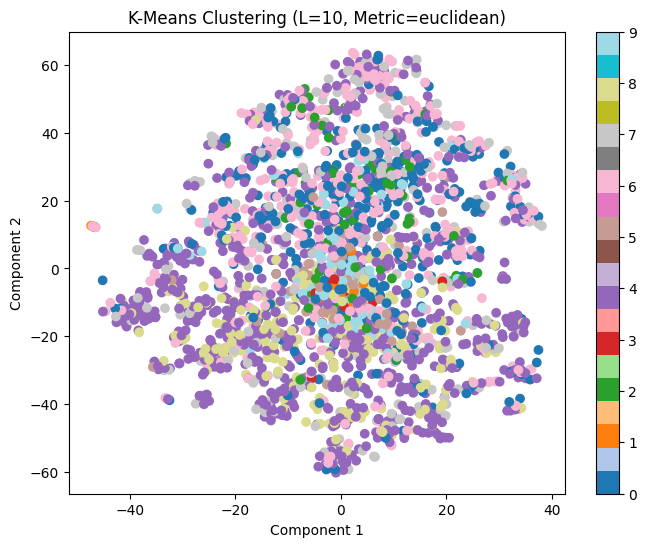

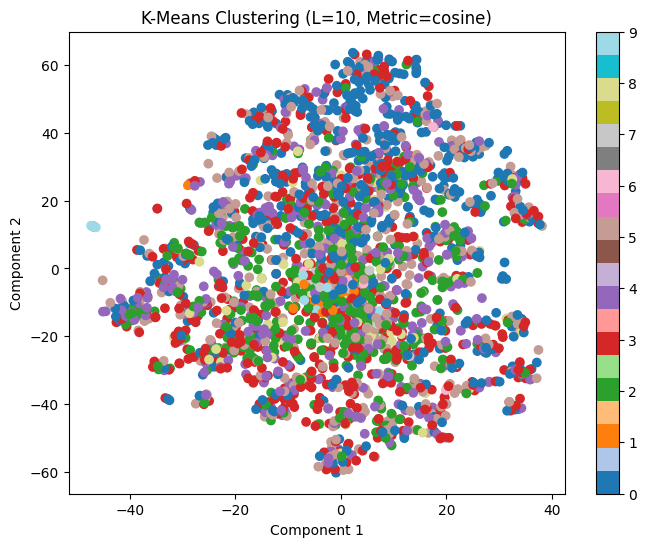

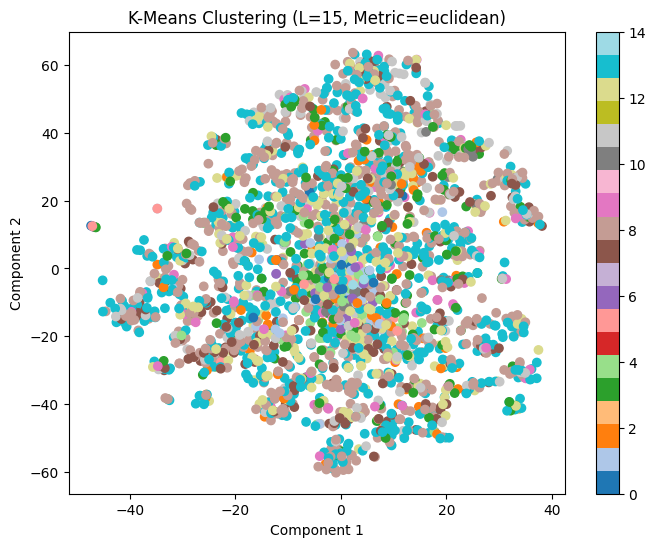

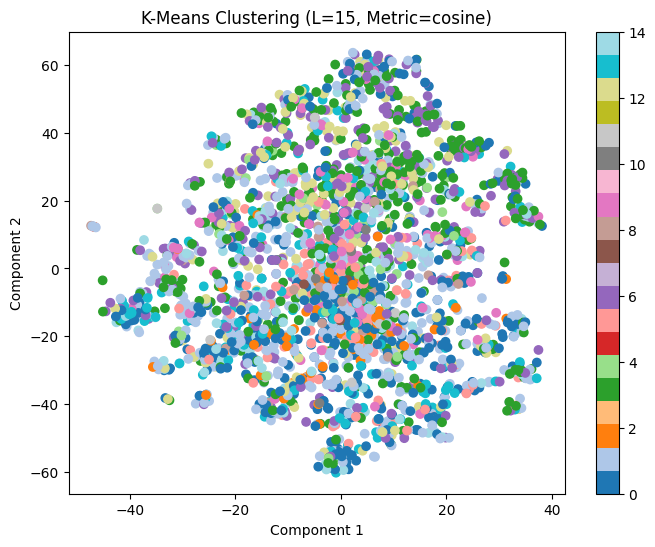

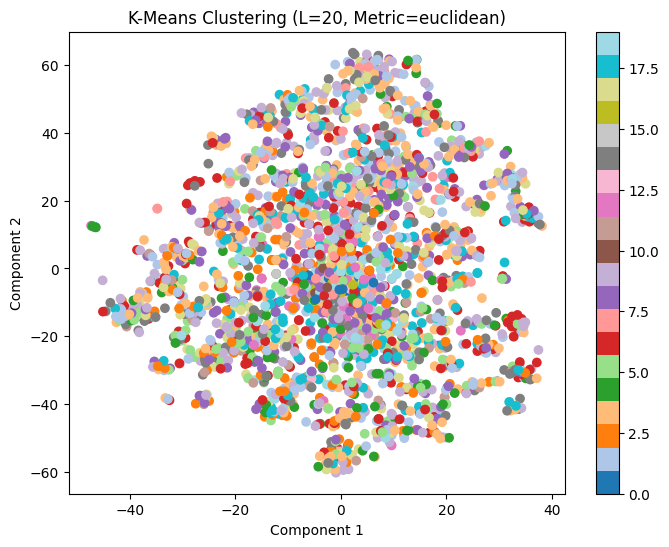

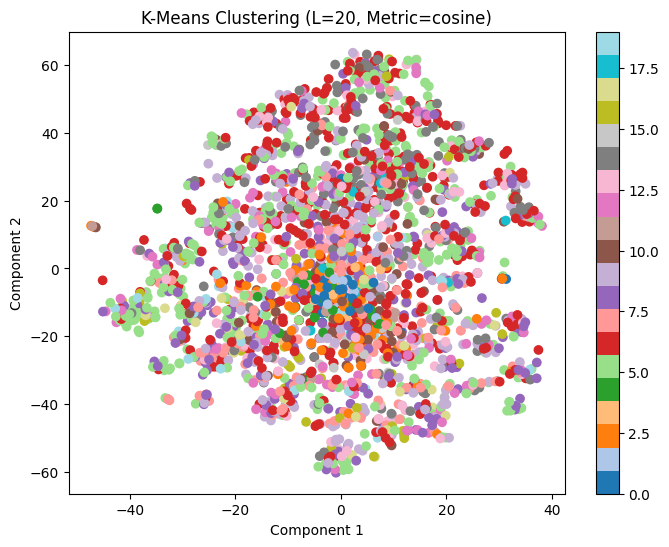

In [9]:
L_values = [10, 15, 20]  # Different values of L (number of clusters)
metrics = ['euclidean', 'cosine']

# Loop through each metric and each value of L
for L in L_values:
    for metric in metrics:
        kmeans = KMeansClustering(k=L, distance_metric=metric, random_state=0)
        
        # Fit the model on the data
        labels = kmeans.fit(user_item_matrix)

        # Reduce dimensions of the data
        svd = TruncatedSVD(n_components=50, random_state=42)
        svd_data = svd.fit_transform(user_item_matrix)
        reducer = TSNE(n_components=2, random_state=42)
        reduced_data = reducer.fit_transform(svd_data)

        # Plot the resulting clusters
        title = f'K-Means Clustering (L={L}, Metric={metric})'
        plot_clusters(reduced_data, labels, title)

### Section 3 -  Recommendation Generation Algorithms Using Artificial Neural Networks
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section, we use a modified version of the k-means algorithm to cluster the users based on their preference vectors. We cluster the users in various numbers of clusters, using a modified euclidean and a modified cosine distance function, plot the results of the clusterings and comment on the effectiveness of the two used distance metrics. <b>For more information on the KMeansClustering class used to cluster the users, see the kmeans.ipynb file, where the code that implements the algorithm resides.</b></p>

#### Section 3.1 -  Clustering using the Jaccard distance
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section we use the Jaccard distance to cluster our data and comment on its drawbacks relative to the metrics of the previous section.</p>

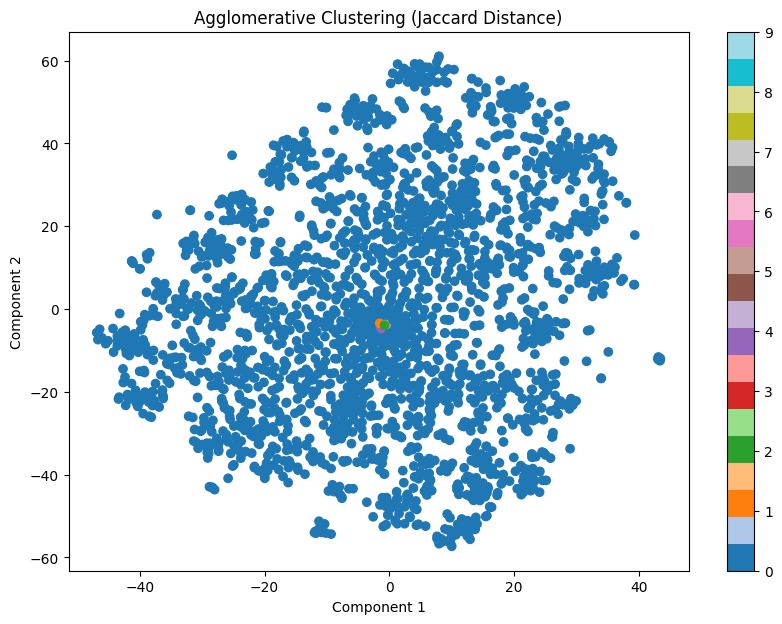

In [8]:
# Create a binary user-item matrix
# 1 if user rated the movie, 0 otherwise
user_item_matrix_binary = coo_matrix(
    (np.ones(filtered_df.shape[0]), (filtered_df['user_idx'], filtered_df['movie_idx'])),
    shape=(len(U_hat), len(I_hat))
).toarray()

# Compute the Jaccard distance matrix between users
jaccard_distances = pairwise_distances(user_item_matrix_binary, metric='jaccard')

# Perform Agglomerative Clustering using the Jaccard distance matrix
clustering_model = AgglomerativeClustering(n_clusters=10, metric='precomputed', linkage='average')
cluster_labels = clustering_model.fit_predict(jaccard_distances)

# Visualize clusters using dimensionality reduction
svd = TruncatedSVD(n_components=50, random_state=42)
svd_data = svd.fit_transform(user_item_matrix_binary)
reducer = TSNE(n_components=2, random_state=42)
reduced_data = reducer.fit_transform(svd_data)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='tab20')
plt.title('Agglomerative Clustering (Jaccard Distance)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.colorbar(scatter)
plt.show()

<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The metric of this section, also known as Jaccard distance, represents the difference between two users, based on how similar the groups of movies they have rated are. The more the common movies they have rated, the more similar the users are considered. Jaccard distances have a value between 0 and 1, with 0 meaning that the users have rated exactly the same movies and with 1 meaning that the users have rated completely different movies. This metric takes into account only which movies the users have rated, but not the actual ratings the users have left for the movies. This is the main drawback this metric has in comparison with the metrics of section two. The Jaccard metric clusters users based only on which movies they have rated, overlooking important aspects of the data, like the actual magnitude and pattern of the user ratings, thus providing less reliable and meaningful metrics. The problem becomes more apparent when inspecting a small slice of the data, like we do in the example above. In the example, we perofrm the clustering only on the users that have left 30 to 35 reviews. In this example, although there is a lot of variation in the magnitudes of the data, the number of reviews each user has left falls within a very specific range and because of this, almost all users are grouped in the same cluster. In summary, the Jaccard metric ignores a lot of nuance in our data and is not able to produce very meaningful clusters.</p>

#### Section 3.2 - Predicting user ratings using their k-nearest neighbors
<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this section we use the Jaccard distance to find the k-nearest neighbors of the users, so we can train models for each cluster that predict the preferences of a user.</p>

In [11]:
# Assuming you have already computed the Jaccard distances and obtained the clusters
# Let's say cluster_labels is the array containing the cluster assignment for each user

k = 5  # Number of nearest neighbors
n_clusters = len(np.unique(cluster_labels))  # Number of clusters

# Initialize dictionaries to store the trained models and MAE (Mean Absolute Error) metrics for each cluster
models = {}
training_mae = {}
testing_mae = {}

# Track which clusters have been successfully processed
clusters_processed = []

# Iterate over each cluster
for cluster in range(n_clusters):
    # Identify the indices of users belonging to the current cluster
    cluster_users = np.where(cluster_labels == cluster)[0]

    # Skip this cluster if the number of users is too small to select k nearest neighbors
    if cluster_users.size < k + 1:
        continue
    
    # Extract the user-item interaction matrix for users in this cluster
    cluster_user_item_matrix = user_item_matrix[cluster_users, :].toarray()
    
    # Calculate the Jaccard distance matrix for all users within this cluster
    cluster_jaccard_distances = pairwise_distances(cluster_user_item_matrix, metric='jaccard')
    
    # Initialize lists to store the input features (X) and target outputs (y) for training the neural network
    X = []
    y = []
    
    # Iterate over each user in the cluster
    for i, user in enumerate(cluster_users):
        # Find the indices of the k-nearest neighbors for the current user, excluding the user itself
        nearest_neighbors_idx = np.argsort(cluster_jaccard_distances[i])[1:k+1]
        
        # Gather the ratings of the k-nearest neighbors
        neighbor_ratings = cluster_user_item_matrix[nearest_neighbors_idx, :]
        
        # Flatten the neighbor ratings into a single vector and add it to the input list
        X.append(neighbor_ratings.flatten())
        
        # The target output is the user's own rating vector
        y.append(cluster_user_item_matrix[i])
    
    # Convert the input and output lists to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    # Split the data into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Define the architecture of the neural network model
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer with 128 neurons
    model.add(Dense(64, activation='relu'))                               # Second hidden layer with 64 neurons
    model.add(Dense(y_train.shape[1], activation='linear'))               # Output layer with linear activation
    
    # Compile the model using Adam optimizer and mean squared error loss function
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Train the model on the training data
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
    
    # Store the trained model in the dictionary with the cluster number as the key
    models[cluster] = model

    # Make predictions on the training set
    y_train_pred = model.predict(X_train)

    # Make predictions on the testing set
    y_test_pred = model.predict(X_test)

    # Calculate the Mean Absolute Error (MAE) on the training set and store it for the current cluster
    training_mae[cluster] = mean_absolute_error(y_train, y_train_pred)

    # Calculate the Mean Absolute Error (MAE) on the testing set and store it for the current cluster
    testing_mae[cluster] = mean_absolute_error(y_test, y_test_pred)

    # Keep track of which clusters have been processed
    clusters_processed.append(cluster)

# Print the MAE results for each processed cluster
for cluster in clusters_processed:
    print(f"Cluster {cluster + 1}:")  # Cluster numbers are 1-based for display
    print(f"  Training MAE: {training_mae[cluster]}")  # Print the training MAE
    print(f"  Testing MAE: {testing_mae[cluster]}")   # Print the testing MAE

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0528 - val_loss: 0.0534
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0533 - val_loss: 0.0533
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0535 - val_loss: 0.0531
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0521 - val_loss: 0.0531
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0532 - val_loss: 0.0530
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0530 - val_loss: 0.0530
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0526 - val_loss: 0.0530
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0537 - val_loss: 0.0529
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0525 - val_loss: 0.0529
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0522 - val_loss: 0.0529
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Cluster 1:
  Training MAE: 0.019458982783917955
  Testing M

<p style="text-align: justify">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</p>